In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 69.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 103.7 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# Cell 1: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments
)

In [3]:
from huggingface_hub import login

login("")

In [4]:
# 1: Load and simple convert on dataset
from datasets import load_dataset
dataset = load_dataset("uitnlp/vigoemotions")

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16531 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2067 [00:00<?, ? examples/s]

In [5]:
import re

NUM_LABELS = 28  # ViGoEmotions

def parse_labels(label_str):
    indices = list(map(int, re.findall(r"\d+", label_str)))
    multi_hot = [0.0] * NUM_LABELS
    for idx in indices:
        multi_hot[idx] = 1.0
    return multi_hot

def preprocess(example):
    example["labels"] = parse_labels(example["labels"])
    return example

dataset = dataset.map(preprocess)

Map:   0%|          | 0/16531 [00:00<?, ? examples/s]

Map:   0%|          | 0/2066 [00:00<?, ? examples/s]

Map:   0%|          | 0/2067 [00:00<?, ? examples/s]

In [6]:
id2label = {
    0: "amusement",
    1: "excitement",
    2: "joy",
    3: "love",
    4: "desire",
    5: "optimism",
    6: "caring",
    7: "pride",
    8: "admiration",
    9: "gratitude",
    10: "relief",
    11: "approval",
    12: "realization",
    13: "surprise",
    14: "curiosity",
    15: "confusion",
    16: "fear",
    17: "nervousness",
    18: "remorse",
    19: "embarrassment",
    20: "disappointment",
    21: "sadness",
    22: "grief",
    23: "disgust",
    24: "anger",
    25: "annoyance",
    26: "disapproval",
    27: "neutral"
}

In [7]:
print(dataset['train'])

Dataset({
    features: ['id', 'text', 'labels'],
    num_rows: 16531
})


In [8]:
# Cell 2: Concatenate all splits
import numpy as np

def get_labels(split):
    return np.array(split["labels"])

Y_train = get_labels(dataset['train'])
#Y_val = get_labels(val)
#Y_test = get_labels(test)

Y = np.vstack(Y_train)  # shape: (N, 28)

In [9]:
# Cell 3: Compute co-occurrence matrix
co_occurrence = Y.T @ Y  # shape: (28, 28)

In [10]:
# Cell 4: Compute Pearson correlation matrix
# Add small epsilon to avoid division by zero
eps = 1e-8
mean = Y.mean(axis=0, keepdims=True)
std = Y.std(axis=0, keepdims=True) + eps

Y_norm = (Y - mean) / std
corr = (Y_norm.T @ Y_norm) / (Y_norm.shape[0] - 1)

In [11]:
# Cell 5: Convert correlation to distance
distance = 1 - corr

In [12]:
# Cell 6: Perform hierarchical clustering (Ward linkage)
from scipy.cluster.hierarchy import linkage

# linkage expects condensed distance matrix
from scipy.spatial.distance import squareform

condensed_dist = squareform(distance, checks=False)
Z = linkage(condensed_dist, method="ward")

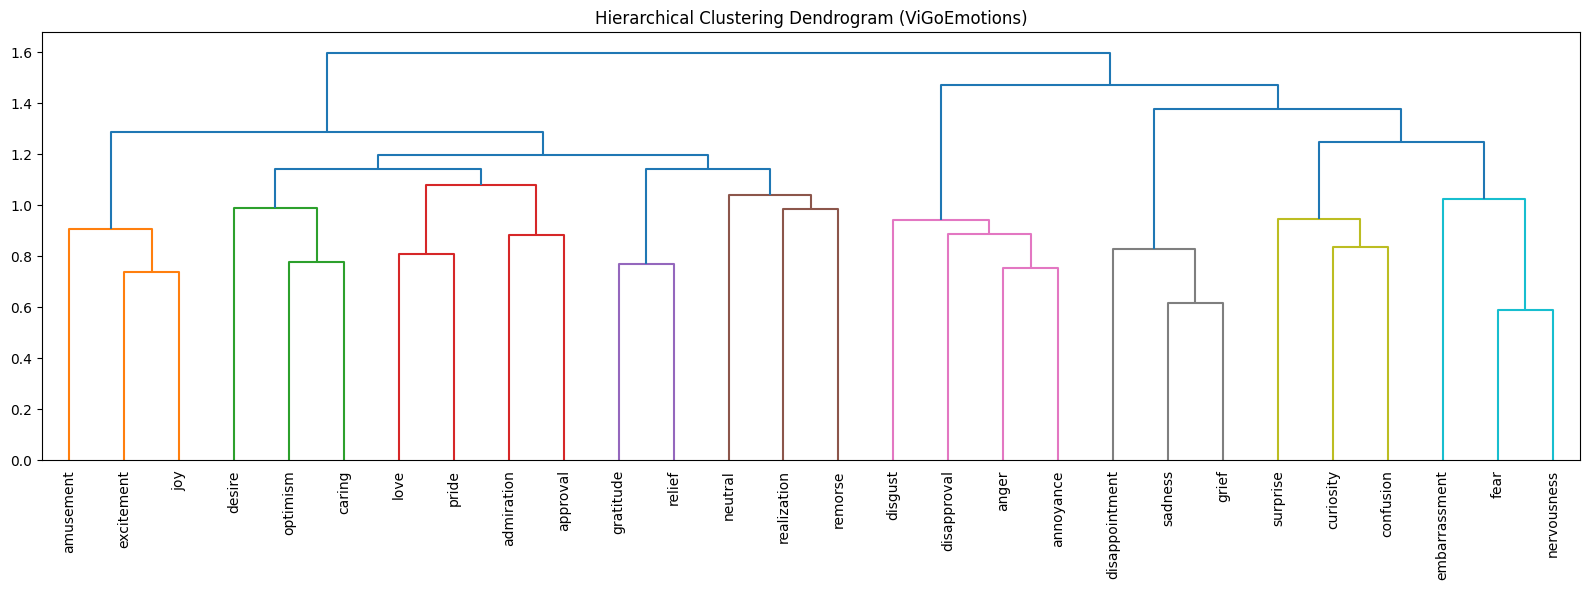

In [13]:
# Cell 7: Plot dendrogram
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

label_names = [id2label[i] for i in range(len(id2label))]

plt.figure(figsize=(16, 6))
dendrogram(Z, labels=label_names, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (ViGoEmotions)")
plt.tight_layout()
plt.show()

In [14]:
# Cell 8: Save dendrogram as image
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

label_names = [id2label[i] for i in range(len(id2label))]

plt.figure(figsize=(16, 6))
dendrogram(Z, labels=label_names, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (ViGoEmotions)")
plt.tight_layout()

plt.savefig("/kaggle/working/dendrogram.png", dpi=300)
plt.close()

In [15]:
# Cell 9: Save merge information (heights + clusters)
import pandas as pd

n_labels = len(id2label)

# Track cluster members
clusters = {i: [id2label[i]] for i in range(n_labels)}

rows = []

for i, (c1, c2, dist, sample_count) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    
    members1 = clusters[c1]
    members2 = clusters[c2]
    
    new_cluster_id = n_labels + i
    clusters[new_cluster_id] = members1 + members2
    
    rows.append({
        "step": i,
        "cluster_1": members1,
        "cluster_2": members2,
        "merged_cluster": members1 + members2,
        "height": dist,
        "size": int(sample_count)
    })

df = pd.DataFrame(rows)

df.to_csv("/kaggle/working/dendrogram_merges.csv", index=False)
df.head()

,step,cluster_1,cluster_2,merged_cluster,height,size
0,0,[fear],[nervousness],"[fear, nervousness]",0.588982,2
1,1,[sadness],[grief],"[sadness, grief]",0.615482,2
2,2,[excitement],[joy],"[excitement, joy]",0.739130,2
3,3,[anger],[annoyance],"[anger, annoyance]",0.752568,2
4,4,[gratitude],[relief],"[gratitude, relief]",0.768339,2


In [16]:
# Cell 13: Define sentiment groups
positive_labels = {
    "admiration","amusement","approval","caring","desire","excitement","gratitude",
    "joy","love","optimism","pride","relief"
}

negative_labels = {
    "anger","annoyance","disappointment","disapproval","disgust",
    "embarrassment","fear","grief","nervousness","remorse","sadness"
}

ambiguous_labels = {
    "confusion","curiosity","realization","surprise","neutral"
}

label_names = [id2label[i] for i in range(len(id2label))]

# Map label index -> group
label_group = {}
for i, name in enumerate(label_names):
    if name in positive_labels:
        label_group[i] = "pos"
    elif name in negative_labels:
        label_group[i] = "neg"
    else:
        label_group[i] = "amb"

In [17]:
# Cell 14: Compute similarity matrix with new mapping rules
import numpy as np
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import squareform

# Cophenetic distances
_, coph_dists = cophenet(Z, condensed_dist)
D = squareform(coph_dists)

# Normalize distances
D_min, D_max = D.min(), D.max()
D_norm = (D - D_min) / (D_max - D_min + 1e-8)

# Parameters
alpha = 2.5   # sharpness
beta = 0.3    # ambiguous scaling

n = D.shape[0]
S = np.zeros_like(D)

for i in range(n):
    for j in range(n):
        if i == j:
            S[i, j] = 1.0
            continue

        base_sim = np.exp(-alpha * D_norm[i, j])  # [0,1]
        
        base_dif = 2 * np.exp(-alpha * D_norm[i, j]) - 1
        
        gi, gj = label_group[i], label_group[j]

        # Same group (pos-pos, neg-neg, amb-amb)
        if gi == gj:
            S[i, j] = base_sim

        # Positive vs Negative → repel
        elif (gi == "pos" and gj == "neg") or (gi == "neg" and gj == "pos"):
            S[i, j] = base_dif

        # Ambiguous with others → weak attraction
        else:
            S[i, j] = beta * base_sim


In [18]:
# Cell 15: Display and save final similarity matrix
import pandas as pd

sim_df = pd.DataFrame(S, index=label_names, columns=label_names)

# Display
sim_df

# Save
sim_df.to_csv("/kaggle/working/label_similarity_matrix_refined.csv")

In [19]:
# Cell 2: Load tokenizer + base model (ViSoBERT encoder)
model_name = "uitnlp/visobert"  # replace

tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModel.from_pretrained(model_name)

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

In [20]:
#def tokenize_fn(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/16531 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

Map:   0%|          | 0/2066 [00:00<?, ? examples/s]

Map:   0%|          | 0/2067 [00:00<?, ? examples/s]

In [44]:
# Cell 3: Define contrastive model with anchors
class ContrastiveViSoBERT(nn.Module):
    def __init__(self, encoder, num_labels):
        super().__init__()
        self.backbone = encoder
        
        self.proj = nn.Linear(self.backbone.config.hidden_size, 256)
        
        # label anchors
        self.anchors = nn.Parameter(torch.randn(num_labels, 256))

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        
        cls = out.last_hidden_state[:, 0]  # CLS token
        z = self.proj(cls)
        
        z = F.normalize(z, dim=-1)
        #anchors = F.normalize(self.anchors, dim=-1)
        
        return z#, anchors

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [45]:
model = ContrastiveViSoBERT(base_model,NUM_LABELS)

In [46]:
print(model.anchors.size())

torch.Size([28, 256])


In [28]:
from torch.utils.data import Dataset, DataLoader
class ViGoDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

dataset_to_train = ViGoDataset(dataset['train']['text'], dataset['train']['labels'])

In [29]:
print(dataset_to_train.labels[0])

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [50]:
# Cell 4: Fixed loss functions using S matrix properly


# Text–Text loss using label-induced similarity via S
def text_text_loss(z, labels, S):
    """
    z: (B, d) normalized text embeddings
    labels: (B, K) multi-hot
    S: (K, K) label similarity matrix
    """
    # predicted text-text similarity
    pred_sim = torch.matmul(z, z.T)  # (B, B)

    # ground-truth similarity induced by labels via S
    target_sim = torch.matmul(torch.matmul(labels.float(), S), labels.float().T)

    loss = F.mse_loss(pred_sim, target_sim)
    return loss


# Text–Anchor loss using S
def text_anchor_loss(z, anchors, labels, S):
    """
    z: (B, d)
    anchors: (K, d)
    labels: (B, K)
    S: (K, K)
    """
    pred = torch.matmul(z, anchors.T)  # (B, K)

    # soft targets: label propagation via similarity matrix
    target = torch.matmul(labels.float(), S)  # (B, K)

    loss = F.mse_loss(pred, target)
    return loss


# Anchor–Anchor loss
def anchor_anchor_loss(anchors, S):
    """
    anchors: (K, d)
    S: (K, K)
    """
    pred = torch.matmul(anchors, anchors.T)  # (K, K)

    loss = F.mse_loss(pred, S)
    return loss

In [30]:
def collate_fn(batch):
    texts, labels = zip(*batch)
    enc = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    labels = torch.stack(labels)
    return enc, labels

In [31]:
# Cell 6: Training arguments
training_args = TrainingArguments(
    output_dir="./visobert_contrastive",
    # Logging
    logging_strategy="steps",
    logging_steps=100,

    # Saving checkpoints
    save_strategy="best",
    #save_steps=100,   # match logging_steps

    # Keep checkpoints manageable
    save_total_limit=5,

    # Optional but useful
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,

    learning_rate= 1e-5,
    per_device_train_batch_size=32,
    #per_device_eval_batch_size=32,
    num_train_epochs=12,
    #weight_decay=0.01,
    report_to="none"
)

In [51]:
# Cell 7: Custom Trainer
class ContrastiveTrainer(Trainer):
    def __init__(self, S_matrix, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.S = torch.tensor(S_matrix, dtype=torch.float).to('cuda')

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        
        
        enc, labels = inputs

        enc = {k: v for k, v in enc.items()}
        z = model(**enc)

        anchors = model.module.anchors if hasattr(model, "module") else model.anchors
        anchors = F.normalize(anchors, dim=-1)
        

        #z, anchors = model(**inputs)
        l1 = text_text_loss(z, labels,self.S)
        l2 = text_anchor_loss(z, anchors, labels,self.S)
        l3 = anchor_anchor_loss(anchors, self.S.to(z.device))
        
        loss = l1 + 0.5 * l2 + 0.2 * l3
        
        return (loss, (z, anchors)) if return_outputs else loss

In [52]:
# Cell 8: Instantiate trainer
trainer = ContrastiveTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset_to_train,
    #tokenizer=tokenizer,
    S_matrix=S,
    #num_labels=28,
    data_collator=collate_fn
)

In [53]:
# Cell 9: Train
trainer.train()

Step,Training Loss
100,4.344295
200,4.060245
300,3.981252
400,3.888994
500,3.768197
600,3.668626
700,3.554839
800,3.502375
900,3.339128
1000,3.489989


TrainOutput(global_step=3108, training_loss=3.35172633805637, metrics={'train_runtime': 2279.601, 'train_samples_per_second': 87.02, 'train_steps_per_second': 1.363, 'total_flos': 0.0, 'train_loss': 3.35172633805637, 'epoch': 12.0})

In [ ]:
anchor_ids = [f"anchor_{i}" for i in range(anchors.size(0))]

In [57]:
anchors = trainer.model.anchors
print(anchors.size())

torch.Size([28, 256])


In [58]:
import numpy as np
import pandas as pd
from tqdm import tqdm


# -------------------------
# 1. Encode function
# -------------------------
def encode_texts(texts, batch_size=64):
    embs = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            z = model(**enc)

        embs.append(z.cpu())

    return torch.cat(embs, dim=0)


# -------------------------
# 2. Build train embeddings index
# -------------------------
train_ids = dataset['train']["id"]
train_texts = dataset['train']["text"]

train_embs = encode_texts(train_texts)  # [N_train, dim]
train_embs = torch.nn.functional.normalize(train_embs, dim=1)




100%|██████████| 259/259 [02:07<00:00,  2.03it/s]


TypeError: unsupported operand type(s) for +: 'Column' and 'list'

In [59]:
print(train_embs.size())

torch.Size([16531, 256])


In [61]:
print(train_ids)

Column(['tik000008', '5743', '32895', 'you001182', '12052', ...])


In [54]:
import torch

def topk_sim(query, candidates, k):
    # query: (D,) or (1, D)
    # candidates: (N, D)
    sims = torch.matmul(query, candidates.T)  # (N,)
    vals, idx = torch.topk(sims, k=k)
    return idx, vals

In [68]:
# -------------------------
# 3. Retrieval function
# -------------------------

def run_retrieval(
    q,
    train_embeddings = train_embs.to('cuda'),
    anchors = anchors,
    train_ids = train_ids,
    topk_text=5,
    topk_anchor=5
):


    # Precompute combined pool
    combined_embeddings = torch.cat([train_embeddings, anchors], dim=0)

    combined_ids = list(train_ids) + [f"anchor_{i}" for i in range(anchors.size(0))]


    # ---- TEXT retrieval ----
    text_idx, text_scores = topk_sim(q, train_embeddings, topk_text)
    retrieved_texts = [
        (train_ids[idx.item()], text_scores[j].item())
        for j, idx in enumerate(text_idx)
    ]

    # ---- ANCHOR retrieval ----
    anchor_idx, anchor_scores = topk_sim(q, anchors, topk_anchor)
    retrieved_anchors = [
        (f"anchor_{idx.item()}", anchor_scores[j].item())
        for j, idx in enumerate(anchor_idx)
    ]

    # ---- COMBINED retrieval ----
    comb_idx, comb_scores = topk_sim(q, combined_embeddings, topk_text + topk_anchor)
    
    retrieved_combined = [
        (combined_ids[idx.item()], comb_scores[j].item())
        for j, idx in enumerate(comb_idx)
    ]


    return retrieved_texts, retrieved_anchors, retrieved_combined


# -------------------------
# 4. Process dev + test
# -------------------------
def process_split(df):
    results = []

    texts = df["text"]
    ids = df["id"]

    query_embs = encode_texts(texts).to('cuda')
    query_embs = torch.nn.functional.normalize(query_embs, dim=1)

    for i in tqdm(range(len(df))):
        sim_texts, sim_anchors, sim_combined = run_retrieval(query_embs[i])

        results.append({
            "query_id": ids[i],
            "similar_texts": [j for j in sim_texts],
            "similar_anchors": [j for j in sim_anchors],
            "similar_combined": [j for j in sim_combined]
        })

    return results


# -------------------------
# 5. Run dev + test
# -------------------------
dev_results = process_split(dataset['validation'])
test_results = process_split(dataset['test'])

100%|██████████| 2067/2067 [06:15<00:00,  5.50it/s]


In [69]:
out_df_dev = pd.DataFrame(dev_results)
out_df_dev.to_csv("retrieval_results_emoembed_dev.csv", index=False)

out_df_test = pd.DataFrame(test_results)
out_df_test.to_csv("retrieval_results_emoembed_test.csv", index=False)

In [72]:
import torch.nn.functional as F

anchors = anchors.detach()
anchors = F.normalize(anchors, dim=-1)
anchors = anchors.cpu()

In [73]:
anchor_dict = {
    f"anchor_{i}": anchors[i]
    for i in range(anchors.size(0))
}

torch.save(anchor_dict, "anchors_with_ids.pt")

In [74]:
df = pd.DataFrame(anchors.numpy())
df.insert(0, "anchor_id", [f"anchor_{i}" for i in range(anchors.size(0))])

df.to_csv("anchors.csv", index=False)